In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Settings
pd.set_option('display.max_columns', 50)
sns.set_theme(style='whitegrid')

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# Load and merge all 4 UNSW-NB15 CSV splits
path = '../data/raw/'

df1 = pd.read_csv(path + 'UNSW-NB15_1.csv', header=None, low_memory=False)
df2 = pd.read_csv(path + 'UNSW-NB15_2.csv', header=None, low_memory=False)
df3 = pd.read_csv(path + 'UNSW-NB15_3.csv', header=None, low_memory=False)
df4 = pd.read_csv(path + 'UNSW-NB15_4.csv', header=None, low_memory=False)

# Merge all splits
df = pd.concat([df1, df2, df3, df4], ignore_index=True)

print(f"Total records: {len(df)}")
print(f"Total columns: {len(df.columns)}")
df.head()

Total records: 2540047
Total columns: 49


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48
0,59.166.0.0,1390,149.171.126.6,53,udp,CON,0.001055,132,164,31,29,0,0,dns,500473.93750,621800.93750,2,2,0,0,0,0,66,82,0,0,0.00000,0.000000,1421927414,1421927414,0.017,0.013000,0.0,0.0,0.0,0,0,0.0,0.0,0,3,7,1,3,1,1,1,NaN,0
1,59.166.0.0,33661,149.171.126.9,1024,udp,CON,0.036133,528,304,31,29,0,0,-,87676.08594,50480.17188,4,4,0,0,0,0,132,76,0,0,9.89101,10.682733,1421927414,1421927414,7.005,7.564333,0.0,0.0,0.0,0,0,0.0,0.0,0,2,4,2,3,1,1,2,NaN,0
2,59.166.0.6,1464,149.171.126.7,53,udp,CON,0.001119,146,178,31,29,0,0,dns,521894.53130,636282.37500,2,2,0,0,0,0,73,89,0,0,0.00000,0.000000,1421927414,1421927414,0.017,0.013000,0.0,0.0,0.0,0,0,0.0,0.0,0,12,8,1,2,2,1,1,NaN,0
3,59.166.0.5,3593,149.171.126.5,53,udp,CON,0.001209,132,164,31,29,0,0,dns,436724.56250,542597.18750,2,2,0,0,0,0,66,82,0,0,0.00000,0.000000,1421927414,1421927414,0.043,0.014000,0.0,0.0,0.0,0,0,0.0,0.0,0,6,9,1,1,1,1,1,NaN,0
4,59.166.0.3,49664,149.171.126.0,53,udp,CON,0.001169,146,178,31,29,0,0,dns,499572.25000,609067.56250,2,2,0,0,0,0,73,89,0,0,0.00000,0.000000,1421927414,1421927414,0.005,0.003000,0.0,0.0,0.0,0,0,0.0,0.0,0,7,9,1,1,1,1,1,NaN,0


In [3]:
# Add column names from the UNSW-NB15 feature list
columns = [
    'srcip', 'sport', 'dstip', 'dsport', 'proto', 'state', 'dur', 'sbytes',
    'dbytes', 'sttl', 'dttl', 'sloss', 'dloss', 'service', 'sload', 'dload',
    'spkts', 'dpkts', 'swin', 'dwin', 'stcpb', 'dtcpb', 'smeansz', 'dmeansz',
    'trans_depth', 'res_bdy_len', 'sjit', 'djit', 'stime', 'ltime', 'sintpkt',
    'dintpkt', 'tcprtt', 'synack', 'ackdat', 'is_sm_ips_ports', 'ct_state_ttl',
    'ct_flw_http_mthd', 'is_ftp_login', 'ct_ftp_cmd', 'ct_srv_src', 'ct_srv_dst',
    'ct_dst_ltm', 'ct_src_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm',
    'ct_dst_src_ltm', 'attack_cat', 'label'
]

df.columns = columns

print("Columns assigned!")
print(df.columns.tolist())

Columns assigned!
['srcip', 'sport', 'dstip', 'dsport', 'proto', 'state', 'dur', 'sbytes', 'dbytes', 'sttl', 'dttl', 'sloss', 'dloss', 'service', 'sload', 'dload', 'spkts', 'dpkts', 'swin', 'dwin', 'stcpb', 'dtcpb', 'smeansz', 'dmeansz', 'trans_depth', 'res_bdy_len', 'sjit', 'djit', 'stime', 'ltime', 'sintpkt', 'dintpkt', 'tcprtt', 'synack', 'ackdat', 'is_sm_ips_ports', 'ct_state_ttl', 'ct_flw_http_mthd', 'is_ftp_login', 'ct_ftp_cmd', 'ct_srv_src', 'ct_srv_dst', 'ct_dst_ltm', 'ct_src_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'attack_cat', 'label']


In [4]:
# Data audit — nulls, dtypes, basic stats
print("=== SHAPE ===")
print(df.shape)

print("\n=== DATA TYPES ===")
print(df.dtypes)

print("\n=== NULL VALUES ===")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("\n=== CLASS DISTRIBUTION ===")
print(df['label'].value_counts())

print("\n=== ATTACK CATEGORIES ===")
print(df['attack_cat'].value_counts())

=== SHAPE ===
(2540047, 49)

=== DATA TYPES ===
srcip                object
sport                object
dstip                object
dsport               object
proto                object
state                object
dur                 float64
sbytes                int64
dbytes                int64
sttl                  int64
dttl                  int64
sloss                 int64
dloss                 int64
service              object
sload               float64
dload               float64
spkts                 int64
dpkts                 int64
swin                  int64
dwin                  int64
stcpb                 int64
dtcpb                 int64
smeansz               int64
dmeansz               int64
trans_depth           int64
res_bdy_len           int64
sjit                float64
djit                float64
stime                 int64
ltime                 int64
sintpkt             float64
dintpkt             float64
tcprtt              float64
synack              float64


In [5]:
# Clean attack_cat — fix spacing/duplicate categories
df['attack_cat'] = df['attack_cat'].str.strip()
df['attack_cat'] = df['attack_cat'].replace({
    'Backdoors': 'Backdoor',
    'Fuzzers': 'Fuzzer',
    'Shellcode': 'Shellcode'
})

# Fill nulls
df['attack_cat'] = df['attack_cat'].fillna('Normal')
df['ct_flw_http_mthd'] = df['ct_flw_http_mthd'].fillna(0)
df['is_ftp_login'] = df['is_ftp_login'].fillna(0)

# Verify
print("=== CLEANED ATTACK CATEGORIES ===")
print(df['attack_cat'].value_counts())

print("\n=== NULL VALUES REMAINING ===")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("Done!")

=== CLEANED ATTACK CATEGORIES ===
attack_cat
Normal            2218764
Generic            215481
Exploits            44525
Fuzzer              24246
DoS                 16353
Reconnaissance      13987
Analysis             2677
Backdoor             2329
Shellcode            1511
Worms                 174
Name: count, dtype: int64

=== NULL VALUES REMAINING ===
Series([], dtype: int64)
Done!


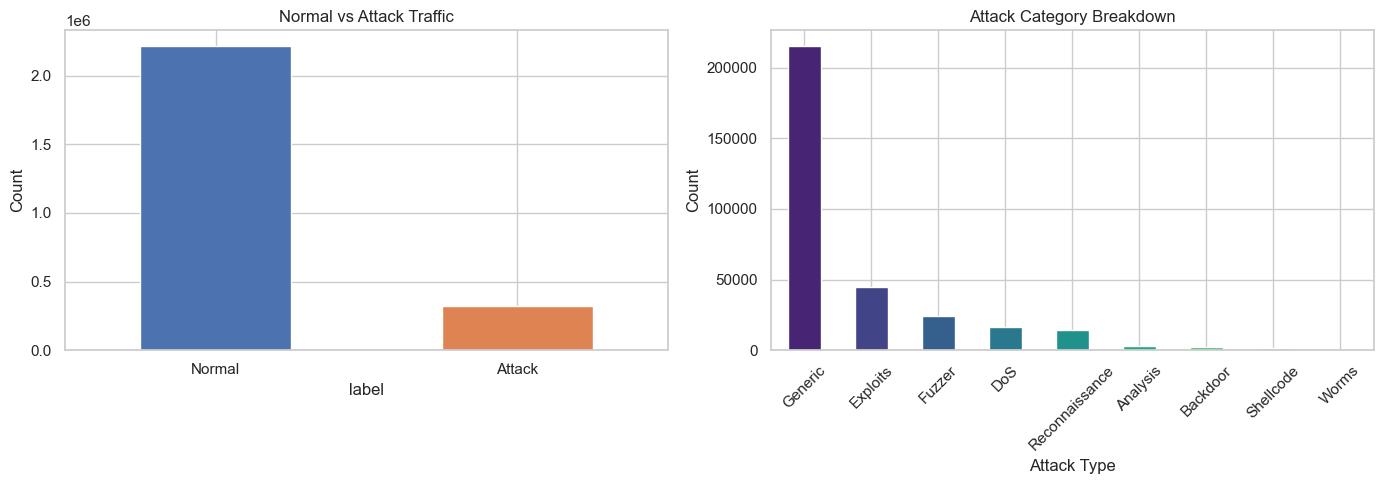

Plot saved!


In [6]:
# Plot 1 — Class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Binary label
df['label'].value_counts().plot(kind='bar', ax=axes[0], color=[sns.color_palette()[0], sns.color_palette()[1]])
axes[0].set_title('Normal vs Attack Traffic')
axes[0].set_xticklabels(['Normal', 'Attack'], rotation=0)
axes[0].set_ylabel('Count')

# Attack categories
df[df['attack_cat'] != 'Normal']['attack_cat'].value_counts().plot(
    kind='bar', ax=axes[1], color=sns.color_palette('viridis', 9)
)
axes[1].set_title('Attack Category Breakdown')
axes[1].set_xlabel('Attack Type')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../reports/eda_class_distribution.png', dpi=150)
plt.show()
print("Plot saved!")

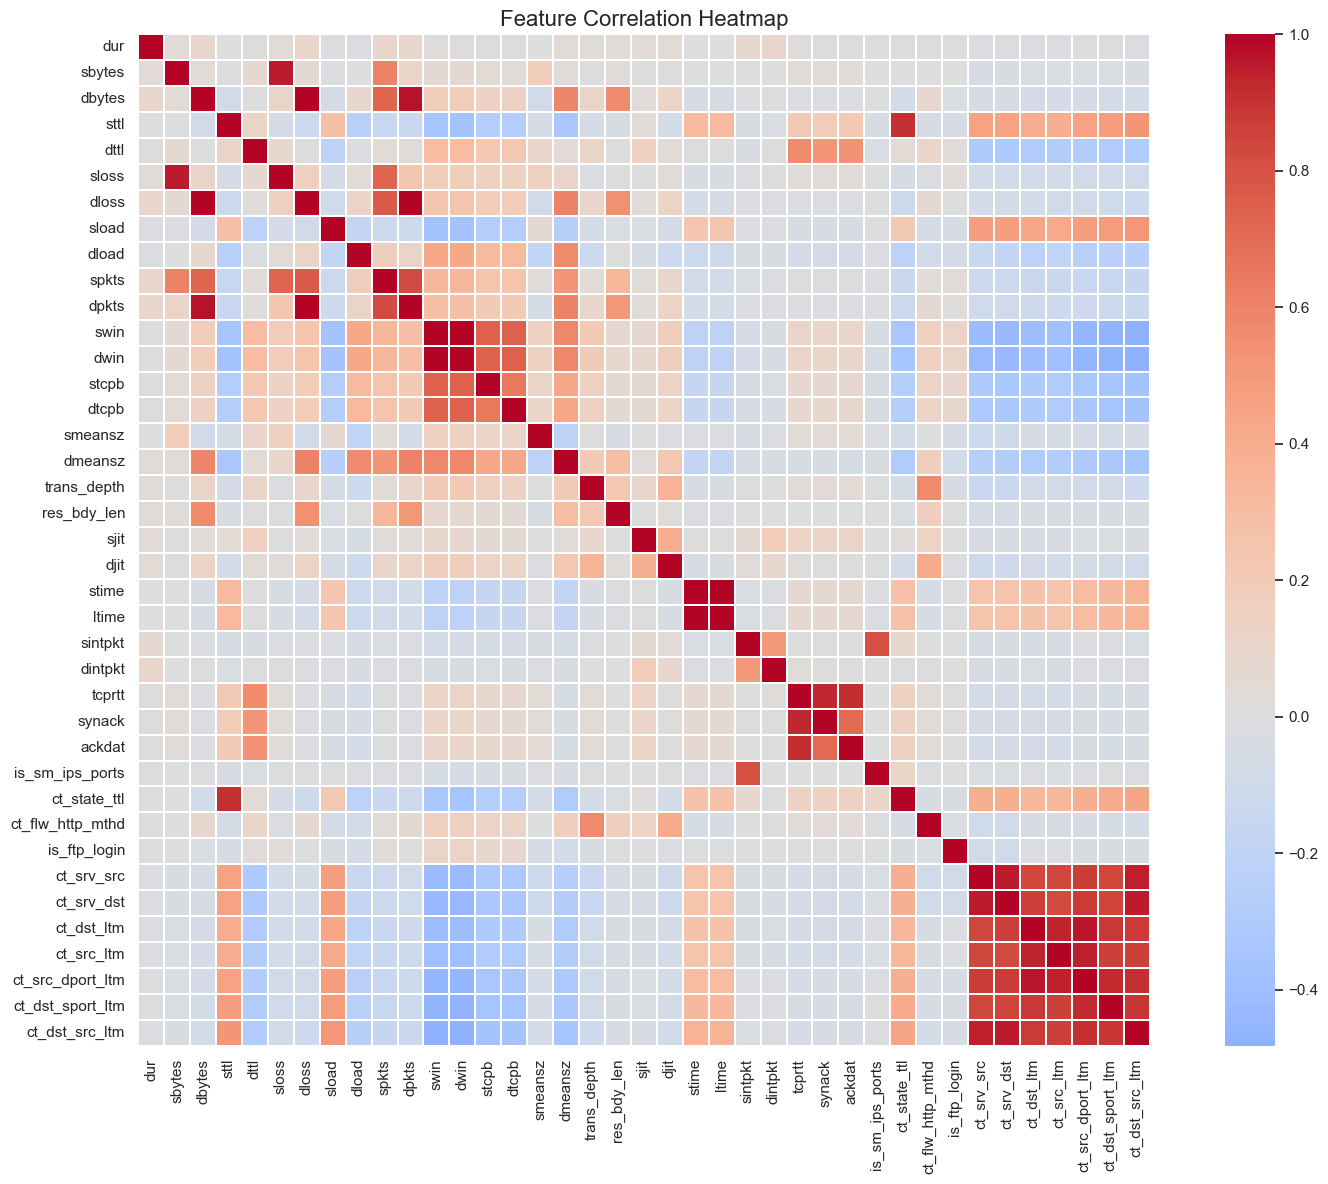

Heatmap saved!


In [7]:
# Plot 2 — Correlation heatmap of numerical features
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numerical_cols = [col for col in numerical_cols if col != 'label']

plt.figure(figsize=(16, 12))
corr_matrix = df[numerical_cols].corr()

sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    center=0,
    linewidths=0.3,
    annot=False,
    square=True
)

plt.title('Feature Correlation Heatmap', fontsize=16)
plt.tight_layout()
plt.savefig('../reports/eda_correlation_heatmap.png', dpi=150)
plt.show()
print("Heatmap saved!")

In [ ]:
# Plot 3 — Traffic volume over time
df['stime_readable'] = pd.to_datetime(df['stime'], unit='s')
df.set_index('stime_readable')['label'].resample('1H').sum().plot(
    figsize=(14, 4), color=sns.color_palette()[1]
)

plt.title('Attack Traffic Volume Over Time')
plt.xlabel('Time')
plt.ylabel('Number of Attacks per Hour')
plt.tight_layout()
plt.savefig('../reports/eda_traffic_over_time.png', dpi=150)
plt.show()
print("Plot saved!")